<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6118/3351479776.py:63: SyntaxWarning: invalid escape sequence '\p'
  ax2.bar(sensor_labels, uniqueness, bottom=communality, label='Uniqueness ($\psi^2$ Noise Floor)', color='firebrick', alpha=0.8, edgecolor='black')


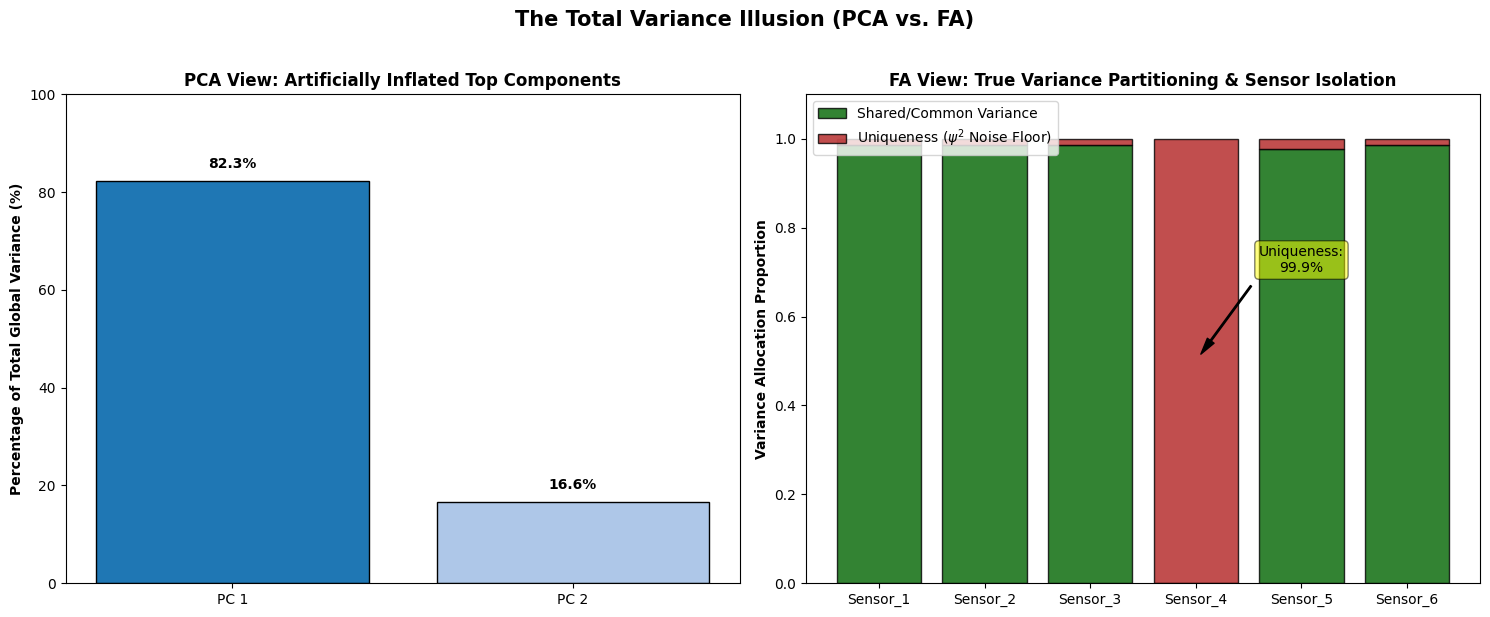


PCA PC1 Explains: 82.29% of total variance
PCA PC2 Explains: 16.64% of total variance
FA Sensor_4 Uniqueness (φ²): 99.85%


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis

# Set seed for exact statistical reproducibility
np.random.seed(24)

n_samples = 1000
n_sensors = 6

# =====================================================================
# 1. GENERATE THE TOTAL VARIANCE ILLUSION DATASET
# =====================================================================
# Real underlying physical process (e.g., a system oscillation)
true_signal = np.sin(np.linspace(0, 50, n_samples))

# Normal sensors track the true underlying process with very little noise
X = np.zeros((n_samples, n_sensors))
for i in range(n_sensors):
    if i != 3: # Sensors 1, 2, 3, 5, 6
        X[:, i] = true_signal * np.random.uniform(0.7, 1.2) + np.random.normal(0, 0.1, n_samples)

# SENSOR 4 EXTRAORDINARY CASE:
# It has almost ZERO relationship to the physical system, but massive localized noise
X[:, 3] = np.random.normal(0, 2.5, n_samples)

# Standardize the dataset (Z-score scaling as done in standard industrial pipelines)
X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# =====================================================================
# 2. RUN PCA AND FACTOR ANALYSIS EXTRACTION
# =====================================================================
# Fit PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)
pca_variance_ratio = pca.explained_variance_ratio_

# Fit Factor Analysis
fa = FactorAnalysis(n_components=1)
fa.fit(X_scaled)
# Uniqueness (psi^2) = Total Variance (1.0 for standardized data) - Communality
communality = np.sum(fa.components_**2, axis=0)
uniqueness = 1.0 - communality

# =====================================================================
# 3. DASHBOARD VISUALIZATION
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot 1: PCA Scree / Variance Illusion ---
bars = ax1.bar(['PC 1', 'PC 2'], pca_variance_ratio * 100, color=['#1f77b4', '#aec7e8'], edgecolor='black')
ax1.set_ylabel('Percentage of Total Global Variance (%)', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_title('PCA View: Artificially Inflated Top Components', fontsize=12, fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

# --- Subplot 2: FA Variance Partitioning Stacked Bar ---
sensor_labels = [f'Sensor_{i+1}' for i in range(n_sensors)]
ax2.bar(sensor_labels, communality, label='Shared/Common Variance', color='darkgreen', alpha=0.8, edgecolor='black')
ax2.bar(sensor_labels, uniqueness, bottom=communality, label='Uniqueness ($\psi^2$ Noise Floor)', color='firebrick', alpha=0.8, edgecolor='black')
ax2.set_ylabel('Variance Allocation Proportion', fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_title('FA View: True Variance Partitioning & Sensor Isolation', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')

# Highlight Sensor 4's massive uniqueness value
ax2.annotate(f'Uniqueness:\n{uniqueness[3]*100:.1f}%', xy=(3, 0.5), xytext=(4, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5), ha='center', fontsize=10)

plt.suptitle('The Total Variance Illusion (PCA vs. FA)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. PRINT NUMERICAL PROOF
# =====================================================================
print("\n" + "="*50)
print(f"PCA PC1 Explains: {pca_variance_ratio[0]*100:.2f}% of total variance")
print(f"PCA PC2 Explains: {pca_variance_ratio[1]*100:.2f}% of total variance")
print(f"FA Sensor_4 Uniqueness (\u03c6\u00b2): {uniqueness[3]*100:.2f}%")
print("="*50)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. SYNTHETIC DATA GENERATION (STRICT SEED)
# ==========================================
np.random.seed(42)
n_samples = 2500

f1 = np.random.normal(0, 1, n_samples)  # Primary structural mode/load
f2 = np.random.normal(0, 1, n_samples)  # Secondary operational mode

s1 = 0.85 * f1 + 0.10 * f2 + np.random.normal(0, 0.3, n_samples)
s2 = 0.80 * f1 + 0.15 * f2 + np.random.normal(0, 0.35, n_samples)
s3 = 0.12 * f1 + 0.90 * f2 + np.random.normal(0, 0.25, n_samples)
s4 = 0.02 * f1 + 0.05 * f2 + np.random.normal(0, 1.40, n_samples)

df_asset = pd.DataFrame(
    data=np.vstack([s1, s2, s3, s4]).T,
    columns=['Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4']
)

# Standardize features using ddof=1 sample standard deviation
X_scaled = StandardScaler().fit_transform(df_asset)
sensor_names = df_asset.columns

# ==========================================
# 2. PCA EIGENVECTOR EXTRACTION
# ==========================================
pca = PCA(n_components=2)
pca.fit(X_scaled)
# Sklearn PCA components represent eigenvectors as rows; transpose to get columns (PC1, PC2)
pca_eigenvectors = pca.components_.T

# ==========================================
# 3. FACTOR ANALYSIS WITH VARIMAX ROTATION
# ==========================================
def varimax_rotation(Phi, gamma=1.0, max_iter=500, tol=1e-6):
    """Orthogonal Varimax rotation to maximize loading variance per factor."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for i in range(max_iter):
        d_old = d
        Lambda = np.dot(Phi, R)
        # SVD step maximizing the variance of squared loadings
        u, s, vh = np.linalg.svd(np.dot(Phi.T, np.asarray(Lambda)**3 - (gamma/p) * np.dot(Lambda, np.diag(np.diag(np.dot(Lambda.T, Lambda))))))
        R = np.dot(u, vh)
        d = np.sum(s)
        if d_old != 0 and abs(d - d_old) < tol:
            break
    return np.dot(Phi, R)

# Extract unrotated loadings using SVD/Maximum Likelihood underlying framework
fa_unrotated = FactorAnalysis(n_components=2, random_state=42)
fa_unrotated.fit(X_scaled)
raw_fa_loadings = fa_unrotated.components_.T

# Apply Varimax rotation
rotated_fa_loadings = varimax_rotation(raw_fa_loadings)

# ==========================================
# 4. PRINT COMPARATIVE MARKING REPORT
# ==========================================
print("=========================================================================")
print("             GEOMETRIC SUBSPACE VS. ROTATED LATENT SUBSPACE             ")
print("=========================================================================\n")

print("--- [1] Raw PCA Eigenvector Matrix (Hierarchical Variance Sweeping) ---")
df_pca = pd.DataFrame(pca_eigenvectors, index=sensor_names, columns=['PC_1', 'PC_2'])
print(df_pca.round(4))
print("\n" + "-"*73 + "\n")

print("--- [2] Varimax-Rotated FA Loadings Matrix (Simple Structure) ---")
df_fa = pd.DataFrame(rotated_fa_loadings, index=sensor_names, columns=['Factor_1', 'Factor_2'])
print(df_fa.round(4))
print("\n=========================================================================")

             GEOMETRIC SUBSPACE VS. ROTATED LATENT SUBSPACE             

--- [1] Raw PCA Eigenvector Matrix (Hierarchical Variance Sweeping) ---
            PC_1    PC_2
Sensor_1  0.6615 -0.1275
Sensor_2  0.6741 -0.1011
Sensor_3  0.3212  0.2675
Sensor_4  0.0701  0.9497

-------------------------------------------------------------------------

--- [2] Varimax-Rotated FA Loadings Matrix (Simple Structure) ---
          Factor_1  Factor_2
Sensor_1    0.9300    0.0040
Sensor_2    0.9246   -0.1436
Sensor_3    0.2129   -0.4824
Sensor_4    0.0339   -0.0867



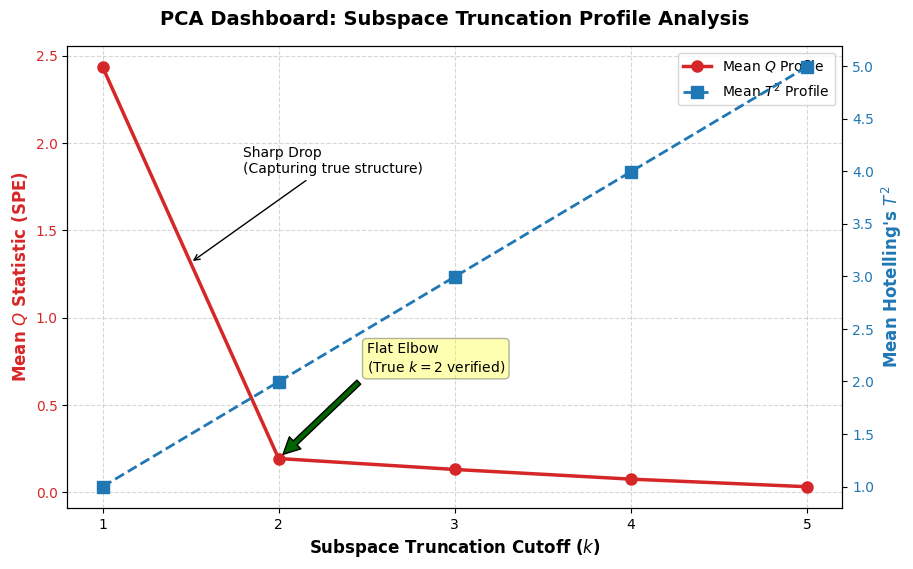


       NUMERIC VALUES FOR YOUR REPORT
            Mean Q Statistic (SPE)  Mean T^2 Statistic
Cutoff (k)                                            
1                           2.4360              0.9987
2                           0.1937              1.9975
3                           0.1312              2.9963
4                           0.0758              3.9950
5                           0.0324              4.9938


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Set seed for exact statistical reproducibility
np.random.seed(42)

# =====================================================================
# 1. SIMULATE PHYSICAL SYSTEM WITH TRUE DIMENSIONALITY (k_true = 2)
# =====================================================================
n_samples = 800
n_sensors = 6

# Two distinct, underlying physical processes driving the asset
latent_1 = np.sin(np.linspace(0, 20, n_samples))
latent_2 = np.sign(np.sin(np.linspace(0, 10, n_samples))) # square-like feature
Latent_True = np.column_stack((latent_1, latent_2))

# Mixing matrix mapping 2 physical factors to 6 sensors
Lambda = np.array([
    [0.85, 0.05],
    [0.70, -0.35],
    [0.15, 0.90],
    [-0.20, 0.75],
    [0.60, 0.40],
    [0.45, -0.60]
])

# Sensor measurement noise (random white noise floor)
sensor_noise = np.random.normal(0, 0.15, size=(n_samples, n_sensors))

# Generate measured data and standardize
X_raw = Latent_True @ Lambda.T + sensor_noise
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)
X_scaled = (X_raw - X_mean) / X_std

# =====================================================================
# 2. EVALUATE METRICS ACROSS SUBSPACE TRUNCATION CUTOFFS (k = 1 to 5)
# =====================================================================
cutoffs = np.arange(1, 6)
mean_T2_profile = []
mean_Q_profile = []

for k in cutoffs:
    # Initialize PCA with current cutoff k
    pca = PCA(n_components=k)

    # FIXED: Combined fit and transform so internal attributes are populated correctly
    scores = pca.fit_transform(X_scaled)
    loadings = pca.components_

    # --- Reconstruct data to find residuals ---
    X_reconstructed = scores @ loadings
    residuals = X_scaled - X_reconstructed

    # --- Compute Q-statistic (SPE) per sample, then find the Mean ---
    Q_samples = np.sum(residuals**2, axis=1)
    mean_Q_profile.append(np.mean(Q_samples))

    # --- Compute Hotelling's T^2 per sample, then find the Mean ---
    # Variance of each principal component (eigenvalues)
    eigenvalues = pca.explained_variance_
    T2_samples = np.sum((scores**2) / eigenvalues, axis=1)
    mean_T2_profile.append(np.mean(T2_samples))

# =====================================================================
# 3. GENERATE THE PCA DASHBOARD
# =====================================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-Axis: Mean Q Statistic Profile
color = 'tab:red'
ax1.set_xlabel('Subspace Truncation Cutoff ($k$)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean $Q$ Statistic (SPE)', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(cutoffs, mean_Q_profile, color=color, marker='o', linewidth=2.5, markersize=8, label='Mean $Q$ Profile')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Annotate the specific transitions requested in the question
ax1.annotate('Sharp Drop\n(Capturing true structure)', xy=(1.5, (mean_Q_profile[0]+mean_Q_profile[1])/2),
             xytext=(1.8, mean_Q_profile[0]*0.75),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

ax1.annotate('Flat Elbow\n(True $k=2$ verified)', xy=(2.0, mean_Q_profile[1]),
             xytext=(2.5, mean_Q_profile[1]+0.5),
             arrowprops=dict(facecolor='darkgreen', shrink=0.05),
             bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3), fontsize=10)

# Right Y-Axis: Mean Hotelling's T^2 Profile
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel("Mean Hotelling's $T^2$", color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(cutoffs, mean_T2_profile, color=color, marker='s', linestyle='--', linewidth=2, markersize=8, label="Mean $T^2$ Profile")
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('PCA Dashboard: Subspace Truncation Profile Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xticks(cutoffs)
plt.show()

# =====================================================================
# 4. PRINT NUMERIC SUMMARY FOR WRITTEN REPORT
# =====================================================================
df_metrics = pd.DataFrame({
    'Cutoff (k)': cutoffs,
    'Mean Q Statistic (SPE)': mean_Q_profile,
    'Mean T^2 Statistic': mean_T2_profile
}).set_index('Cutoff (k)')

print("\n" + "="*40)
print("       NUMERIC VALUES FOR YOUR REPORT")
print("="*40)
print(df_metrics.round(4))
print("="*40)

✅ Normal baseline data generated and standardized.
Estimated Sensor Uniqueness Noise Floor (psi^2) via FA:
  Sensor 1: 0.1459
  Sensor 2: 0.1390
  Sensor 3: 0.1294
  Sensor 4: 0.1221
  Sensor 5: 0.2574
  Sensor 6: 0.1579


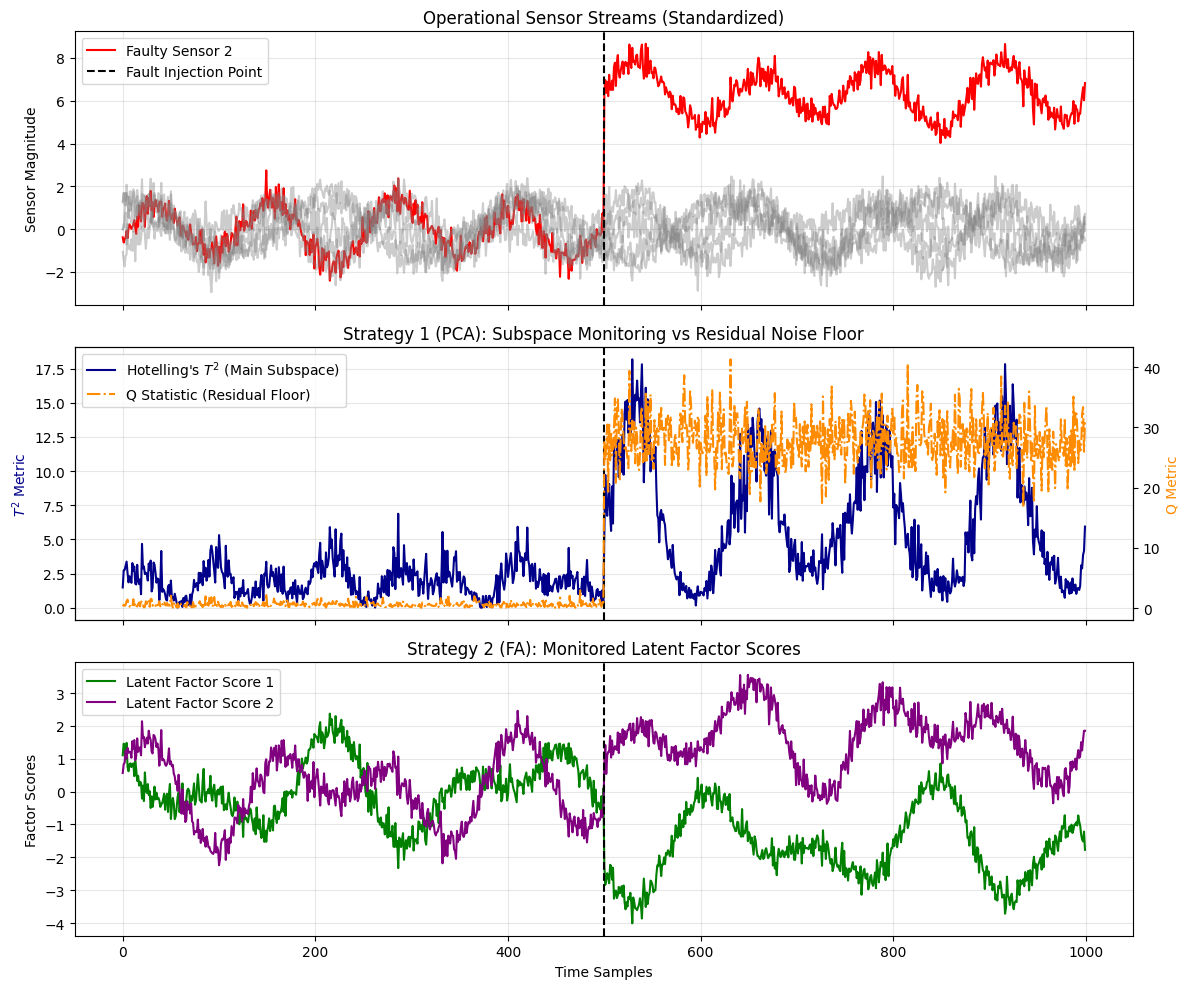

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis
from scipy.stats import f, chi2

# Set random seed for reproducibility
np.random.seed(42)

# =====================================================================
# 1. SIMULATE NORMAL OPERATING DATA (Fleet of Industrial Assets)
# =====================================================================
# Assume 6 sensors tracking 2 underlying physical latent factors (e.g., Temp, Vibration)
n_samples = 1000
n_sensors = 6

# Latent true processes
latent_1 = np.sin(np.linspace(0, 50, n_samples)) + np.random.normal(0, 0.1, n_samples)
latent_2 = np.cos(np.linspace(0, 30, n_samples)) + np.random.normal(0, 0.1, n_samples)
Latent_True = np.column_stack((latent_1, latent_2))

# Mixing matrix (how latent factors manifest in sensors)
Lambda = np.array([
    [0.8, 0.1],
    [0.7, -0.2],
    [0.1, 0.9],
    [-0.3, 0.8],
    [0.5, 0.4],
    [0.4, -0.5]
])

# Sensor-specific unique noise (Sensor Uniqueness Floor \psi^2)
# Let's give Sensor 2 (index 1) a relatively low inherent noise baseline normally
psi_squared_true = np.array([0.05, 0.04, 0.06, 0.05, 0.07, 0.04])
unique_noise = np.random.normal(0, np.sqrt(psi_squared_true), size=(n_samples, n_sensors))

# Generate normal sensor data: X = Z*L^T + e
X_normal = Latent_True @ Lambda.T + unique_noise

# Standardize data (crucial for both PCA and FA)
X_mean = np.mean(X_normal, axis=0)
X_std = np.std(X_normal, axis=0)
X_normal_scaled = (X_normal - X_mean) / X_std

print("✅ Normal baseline data generated and standardized.")

# =====================================================================
# 2. TRAIN THE MONITORS (PCA vs. FA)
# =====================================================================
n_components = 2

# --- Strategy 1: PCA ---
pca = PCA(n_components=n_components)
pca.fit(X_normal_scaled)

# Calculate Hotelling's T^2 thresholds and Q thresholds for PCA baseline
P = pca.components_.T # Loading matrix (n_sensors x n_components)
Lambda_pca = np.diag(pca.explained_variance_) # Eigenvalues

# --- Strategy 2: Factor Analysis ---
# FA explicitly models the diagonal uniqueness matrix \Psi^2
fa = FactorAnalysis(n_components=n_components)
fa.fit(X_normal_scaled)
psi_squared_estimated = fa.noise_variance_ # Estimated \psi^2 for each sensor

print("Estimated Sensor Uniqueness Noise Floor (psi^2) via FA:")
for i, val in enumerate(psi_squared_estimated):
    print(f"  Sensor {i+1}: {val:.4f}")

# =====================================================================
# 3. SIMULATE SENSOR FAULT (Calibration Loss / Electrical Short)
# =====================================================================
# Create a test dataset where an anomaly occurs halfway through
X_test = X_normal.copy()

# Inject a sudden bias / short-circuit drift in Sensor 2 (Index 1) at t >= 500
fault_start = 500
sensor_fault_idx = 1
X_test[fault_start:, sensor_fault_idx] += 3.5 # Massive step/drift fault

# Scale test data using training baseline parameters
X_test_scaled = (X_test - X_mean) / X_std

# =====================================================================
# 4. RUN ONLINE MONITORING STRATEGIES
# =====================================================================

# --- 4.1 PCA Strategy Execution ---
# Project to subspace
Scores_PCA = pca.transform(X_test_scaled)
X_projected_PCA = Scores_PCA @ P.T

# Hotelling's T^2 Calculation
inv_Cov_PCA = np.linalg.inv(Lambda_pca)
T2_statistic = np.zeros(n_samples)
for i in range(n_samples):
    T2_statistic[i] = Scores_PCA[i] @ inv_Cov_PCA @ Scores_PCA[i].T

# Q-Statistic (Squared Prediction Error) Calculation
Residuals_PCA = X_test_scaled - X_projected_PCA
Q_statistic = np.sum(Residuals_PCA**2, axis=1)


# --- 4.2 FA Strategy Execution ---
# Latent Factor Scores directly
Scores_FA = fa.transform(X_test_scaled)

# =====================================================================
# 5. VISUALIZATION & COMPARISON
# =====================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Raw Sensor Readings (Fault highlighted)
axes[0].plot(X_test_scaled[:, sensor_fault_idx], color='red', label=f'Faulty Sensor {sensor_fault_idx+1}')
non_faulty_idx = [i for i in range(n_sensors) if i != sensor_fault_idx]
axes[0].plot(X_test_scaled[:, non_faulty_idx], color='gray', alpha=0.4)
axes[0].axvline(x=fault_start, color='black', linestyle='--', label='Fault Injection Point')
axes[0].set_title("Operational Sensor Streams (Standardized)")
axes[0].set_ylabel("Sensor Magnitude")
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: PCA Strategy Metrics (T2 and Q)
ax2_twin = axes[1].twinx()
p1, = axes[1].plot(T2_statistic, color='darkblue', label="Hotelling's $T^2$ (Main Subspace)")
p2, = ax2_twin.plot(Q_statistic, color='darkorange', linestyle='-.', label="Q Statistic (Residual Floor)")
axes[1].axvline(x=fault_start, color='black', linestyle='--')
axes[1].set_title("Strategy 1 (PCA): Subspace Monitoring vs Residual Noise Floor")
axes[1].set_ylabel("$T^2$ Metric", color='darkblue')
ax2_twin.set_ylabel("Q Metric", color='darkorange')
axes[1].legend(handles=[p1, p2], loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot 3: FA Strategy Metrics (Factor Scores)
axes[2].plot(Scores_FA[:, 0], label="Latent Factor Score 1", color='green')
axes[2].plot(Scores_FA[:, 1], label="Latent Factor Score 2", color='purple')
axes[2].axvline(x=fault_start, color='black', linestyle='--')
axes[2].set_title("Strategy 2 (FA): Monitored Latent Factor Scores")
axes[2].set_ylabel("Factor Scores")
axes[2].set_xlabel("Time Samples")
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()